# Model C₂ — Class-1 abandonments only on $\widetilde{S}$
### $\theta_1 > 0$,  $\gamma_1 = \gamma_2 = \theta_2 = 0$

Class-1 customers abandon the queue at per-customer rate $\theta_1$. In state
space $\widetilde{S}$, abandonment of a class-1 customer reduces $n$ by 1 while
keeping $n_2$ fixed: the transition is $(n_2, n) \to (n_2, n-1)$ at rate
$\theta_1(n-n_2) = \theta_1 n_1$.

Key consequences (from the thesis Corollary 7):
$$\pi_0 = \frac{1-\lambda_2\mathbb{E}[B_C]}{1+\lambda_1\mathbb{E}[B_C]}, \qquad
\pi(0,0) = (\rho_1+\rho_2)\,\pi_0,$$
where $\mathbb{E}[B_C] = {}_1F_1(1;\mu/\theta_1{+}1;\lambda_1/\theta_1)/\mu$
is the mean busy period of the $M/M/1{+}M$ subsystem.
As $\theta_1\to0$, these recover $\pi_0=1-\rho$ and $\pi(0,0)=\rho(1-\rho)$.

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, simulate_tilde,
    convert_S_to_Stilde,
    P_tilde, marginals_tilde, diagnostics_tilde,
    P_tilde_approx_modelA, y_star,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

# ── shared plotting helpers ───────────────────────────────────────────────────

def tilde_heatmap(ax, pi_tilde, title, nmax=12, log=False, vmin=None, vmax=None):
    grid = pi_tilde[:nmax+1, :nmax+1].copy()
    n2i, ni = np.indices(grid.shape)
    grid[n2i > ni] = np.nan
    if log:
        grid = np.where(grid > 0, grid, np.nan)
        vm  = vmin or 1e-6
        vM  = vmax or float(np.nanmax(grid))
        im  = ax.imshow(grid, origin="lower", cmap="viridis",
                        norm=LogNorm(vmin=vm, vmax=vM))
    else:
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       vmin=vmin or 0, vmax=vmax or float(np.nanmax(grid)))
    ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$n_2$")
    ax.set_title(title)
    ax.plot([0, nmax], [0, nmax], "w--", lw=0.8, alpha=0.6)
    return im

def ppgf_panel(ax, pi_tilde, p, ns=(1,2,3,5,8), show_approx=False, label_suffix=""):
    y = np.linspace(0.0, 1.0, 201)
    cols = plt.cm.viridis(np.linspace(0.15, 0.9, len(ns)))
    for n, c in zip(ns, cols):
        ax.plot(y, P_tilde(y, n, pi_tilde), color=c, lw=2.0,
                label=rf"$n={n}${label_suffix}")
        if show_approx:
            ax.plot(y, P_tilde_approx_modelA(y, n, p), color=c,
                    lw=1.3, ls="--", alpha=0.7)
    ax.set_xlabel(r"$y$"); ax.set_ylabel(r"$\widetilde{P}(y,n)$")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

def marginals_panel(ax, pi_tilde, kmax=14):
    m = marginals_tilde(pi_tilde)
    k = np.arange(min(kmax+1, len(m["pi_n1"])))
    ax.bar(k - 0.2, m["pi_n1"][:len(k)], 0.4, label=r"$\pi(n_1)$",
           color="#1f3a93", alpha=0.85)
    ax.bar(k + 0.2, m["pi_n2"][:len(k)], 0.4, label=r"$\pi(n_2)$",
           color="#c0392b", alpha=0.85)
    ax.set_xlabel("queue count"); ax.set_ylabel("probability")
    ax.legend(); ax.grid(alpha=0.3)

def metrics_row(name, p, r):
    d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    print(f"  {name:<28} pi_0={r['pi_idle']:.4f}  P(busy)={d['P_busy']:.4f}"
          f"  E[N1]={d['E_n1']:.3f}  E[N2]={d['E_n2']:.3f}"
          f"  E[N]={d['E_n']:.3f}  throughput={d['throughput']:.4f}")

In [2]:
from scipy.special import hyp1f1

def E_BC(lam1, mu, theta1):
    if theta1 == 0: return 1.0 / (mu - lam1)
    return hyp1f1(1, mu/theta1 + 1, lam1/theta1) / mu

def pi0_C2(lam1, lam2, mu, theta1):
    eb = E_BC(lam1, mu, theta1)
    return (1 - lam2*eb) / (1 + lam1*eb)

def pi00_C2(lam1, lam2, mu, theta1):
    return (lam1+lam2)/mu * pi0_C2(lam1, lam2, mu, theta1)

lam1, lam2, mu = 0.3, 0.4, 1.0
theta1_vals = [0.0, 0.2, 0.5, 1.0, 2.0]

print(f"{'theta1':>8} {'pi0 formula':>14} {'pi0 numeric':>14} "
      f"{'pi(0,0) formula':>17} {'pi(0,0) numeric':>17}")
print("─" * 75)
for th in theta1_vals:
    if th == 0.0:
        pm = Params(lam1, lam2, mu)
    else:
        pm = Params(lam1, lam2, mu, theta1=th)
    r  = solve_exact_tilde(pm, n_max=60)
    pi0_f  = pi0_C2(lam1, lam2, mu, th) if th > 0 else 1-(lam1+lam2)/mu
    pi00_f = pi00_C2(lam1, lam2, mu, th) if th > 0 else (lam1+lam2)/mu*(1-(lam1+lam2)/mu)
    print(f"{th:>8.2f} {pi0_f:>14.6f} {r['pi_idle']:>14.6f} "
          f"{pi00_f:>17.6f} {r['pi_tilde'][0,0]:>17.6f}")

  theta1    pi0 formula    pi0 numeric   pi(0,0) formula   pi(0,0) numeric
───────────────────────────────────────────────────────────────────────────
    0.00       0.300000       0.300000          0.210000          0.210000
    0.20       0.339698       0.339698          0.237789          0.237789
    0.50       0.369584       0.369584          0.258708          0.258708
    1.00       0.395243       0.395243          0.276670          0.276670
    2.00       0.418577       0.418577          0.293004          0.293004


## 1. Joint distribution: abandonments pull mass toward the diagonal

A class-1 customer who abandons removes a count from $n_1=n-n_2$, moving the
state from $(n_2,n)$ to $(n_2,n-1)$. This *drains the strictly-upper-triangular*
region (large $n_1$) toward the diagonal ($n_1=0$, $n_2=n$).

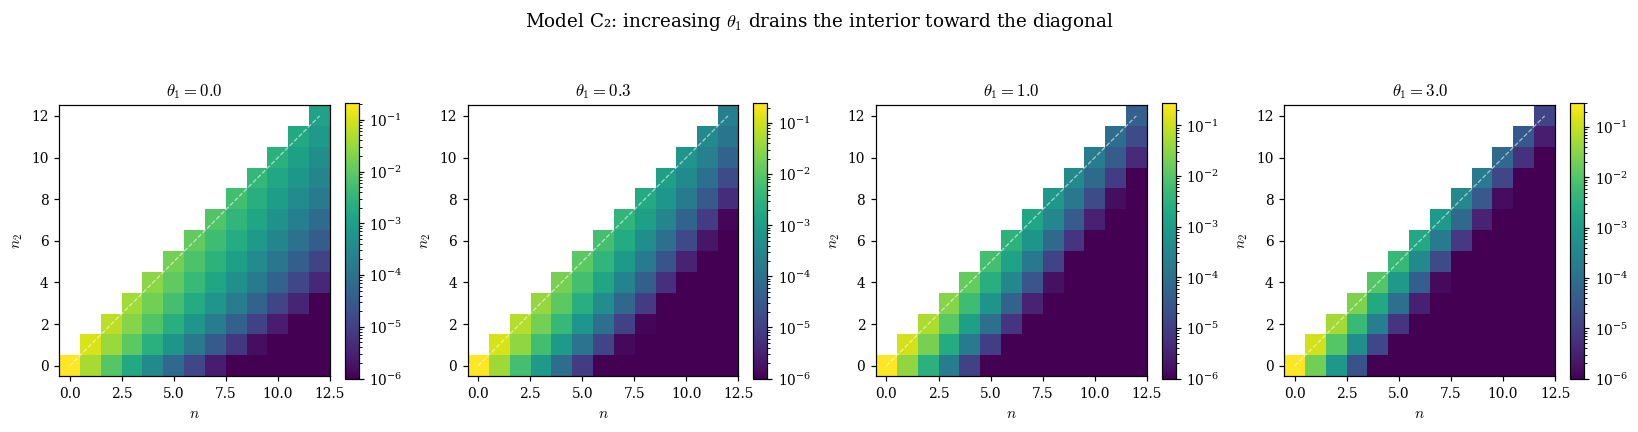

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.0))
for ax, th in zip(axes, [0.0, 0.3, 1.0, 3.0]):
    pm = Params(lam1, lam2, mu, theta1=th)
    r  = solve_exact_tilde(pm, n_max=60)
    im = tilde_heatmap(ax, r["pi_tilde"], rf"$\theta_1={th}$", log=True,
                       vmin=1e-6, vmax=r["pi_tilde"][:13,:13].max())
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(r"Model C₂: increasing $\theta_1$ drains the interior toward the diagonal")
fig.tight_layout()

## 2. PPGF $\widetilde{P}(y,n)$: redistribution under $\theta_1$

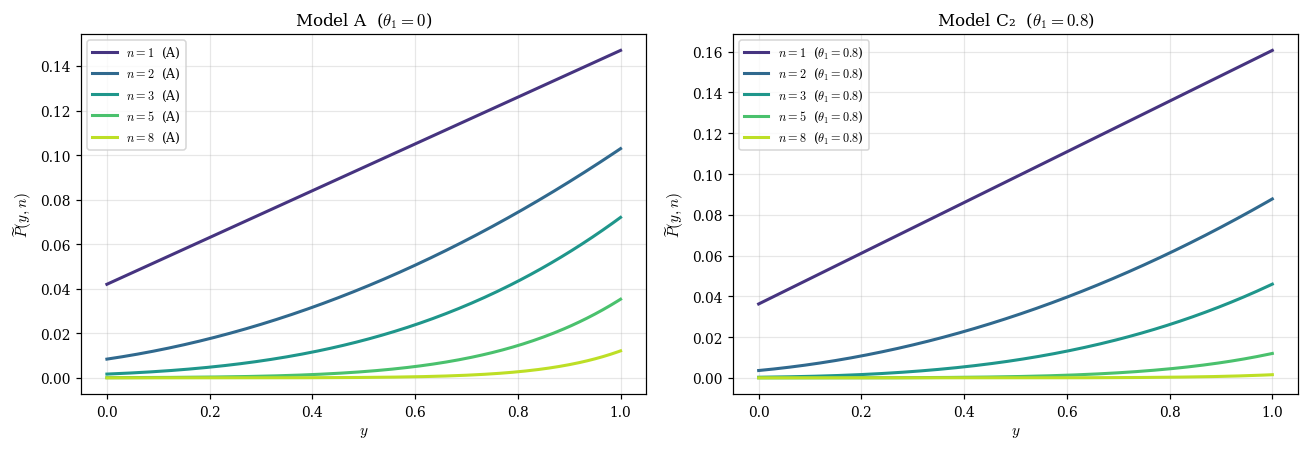

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
r_A = solve_exact_tilde(Params(lam1, lam2, mu), n_max=60)

ppgf_panel(axes[0], r_A["pi_tilde"], Params(lam1, lam2, mu), label_suffix="  (A)")
axes[0].set_title(r"Model A  ($\theta_1=0$)")

th_show = 0.8
r_C = solve_exact_tilde(Params(lam1, lam2, mu, theta1=th_show), n_max=60)
ppgf_panel(axes[1], r_C["pi_tilde"], Params(lam1, lam2, mu, theta1=th_show),
           label_suffix=rf"  ($\theta_1={th_show}$)")
axes[1].set_title(rf"Model C₂  ($\theta_1={th_show}$)")
fig.tight_layout()

## 3. Convergence to Model A as $\theta_1 \to 0$

All metrics ($\pi_0$, $E[N_1]$, $E[N_2]$, throughput) must recover their Model A
values in the limit $\theta_1\to0$.

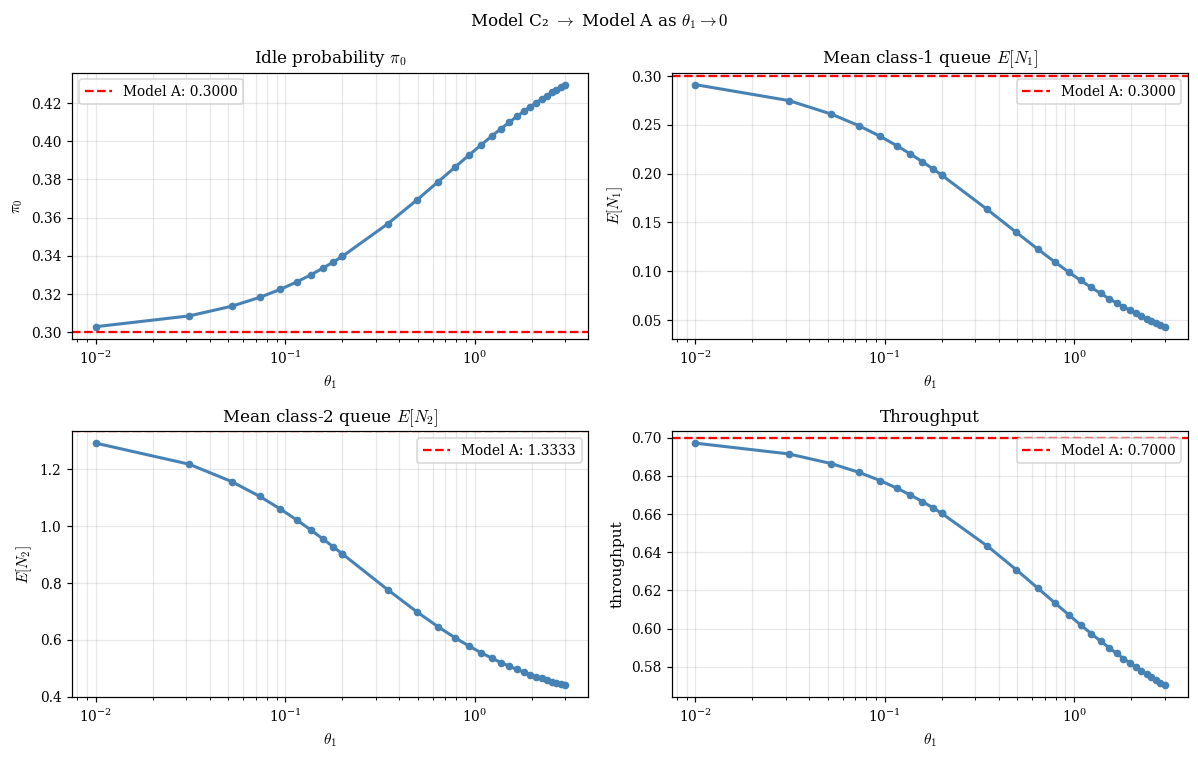

In [5]:
th_range = np.concatenate([np.linspace(0.01, 0.2, 10), np.linspace(0.2, 3.0, 20)])
pi0_list, En1_list, En2_list, thru_list = [], [], [], []
for th in th_range:
    pm = Params(lam1, lam2, mu, theta1=th)
    r  = solve_exact_tilde(pm, n_max=60)
    d  = diagnostics_tilde(pm, r["pi_idle"], r["pi_tilde"])
    pi0_list.append(r["pi_idle"]); En1_list.append(d["E_n1"])
    En2_list.append(d["E_n2"]);   thru_list.append(d["throughput"])

# Model A reference values
r_ref = solve_exact_tilde(Params(lam1, lam2, mu), n_max=60)
d_ref = diagnostics_tilde(Params(lam1, lam2, mu), r_ref["pi_idle"], r_ref["pi_tilde"])

fig, axes = plt.subplots(2, 2, figsize=(11, 7.0))
for ax, vals, ref, ylabel, title in zip(
    axes.flat,
    [pi0_list, En1_list, En2_list, thru_list],
    [r_ref["pi_idle"], d_ref["E_n1"], d_ref["E_n2"], d_ref["throughput"]],
    [r"$\pi_0$", r"$E[N_1]$", r"$E[N_2]$", r"throughput"],
    [r"Idle probability $\pi_0$", r"Mean class-1 queue $E[N_1]$",
     r"Mean class-2 queue $E[N_2]$", "Throughput"],
):
    ax.semilogx(th_range, vals, "o-", color="steelblue", ms=4, lw=2)
    ax.axhline(ref, color="red", ls="--", lw=1.5,
               label=f"Model A: {ref:.4f}")
    ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
fig.suptitle(r"Model C₂ $\to$ Model A as $\theta_1\to0$", fontsize=11)
fig.tight_layout()

## 4. Total queue marginal: abandonments lower $\mathbb{P}(\text{busy})$

Unlike jockeying, abandonments *do* change the total queue marginal: the sum
$\sum_n\widetilde{P}(1,n)=\mathbb{P}(\text{busy})<\rho$ because some customers
leave before service.

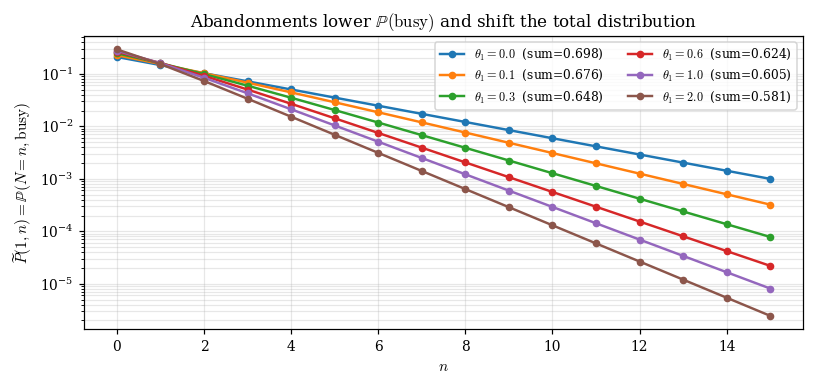

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ns = np.arange(16)
for th in [0.0, 0.1, 0.3, 0.6, 1.0, 2.0]:
    pm = Params(lam1, lam2, mu, theta1=th) if th > 0 else Params(lam1, lam2, mu)
    r  = solve_exact_tilde(pm, n_max=60)
    Pn = [float(P_tilde(1.0, n, r["pi_tilde"])) for n in ns]
    ax.plot(ns, Pn, "o-", ms=4, lw=1.6,
            label=rf"$\theta_1={th}$  (sum={sum(Pn):.3f})")
ax.set_xlabel(r"$n$"); ax.set_yscale("log")
ax.set_ylabel(r"$\widetilde{P}(1, n) = \mathbb{P}(N=n, \mathrm{busy})$")
ax.set_title(r"Abandonments lower $\mathbb{P}(\text{busy})$ and shift the total distribution")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3, which="both")
fig.tight_layout()